In [1]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import numpy as np

In [2]:
print("=== 1단계: 데이터 불러오기 및 병합 ===")
# 게임별 장르 매핑
game_meta = {
    "Elden_Ring": "RPG", "Witcher_3": "RPG", "Cyberpunk_2077": "RPG",
    "PUBG": "FPS", "CS2": "FPS", "R6_Siege": "FPS"
}

df_list = []
for file in os.listdir("data"):
    if file.endswith("_reviews.csv"):
        game_name = file.replace("_reviews.csv", "")
        temp_df = pd.read_csv(f"data/{file}")
        temp_df['Game_Name'] = game_name
        temp_df['Genre'] = game_meta.get(game_name, "Unknown")
        df_list.append(temp_df)

=== 1단계: 데이터 불러오기 및 병합 ===


In [3]:
# 하나로 병합
df = pd.concat(df_list, ignore_index=True)
print(f"병합 직후 데이터 크기: {df.shape}")

병합 직후 데이터 크기: (12000, 5)


In [4]:
print("\n=== 2단계: 데이터 정제 (결측치, 중복값, 타입 처리) ===")
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(subset=['review'], keep='first', inplace=True)
df['voted_up'] = df['voted_up'].astype(int) # True/False를 1/0으로 변환
print(f"정제 후 남은 데이터 크기: {df.shape}")


=== 2단계: 데이터 정제 (결측치, 중복값, 타입 처리) ===
정제 후 남은 데이터 크기: (10044, 5)


In [5]:
print("\n=== 3단계: 자연어 처리(NLP) 및 파생 변수 생성 ===")
def clean_text(text):
    text = str(text).lower() # 소문자 변환
    text = re.sub(r'[^a-z\s]', '', text) # 특수문자 제거++
    text = re.sub(r'\s+', ' ', text).strip() # 다중 공백 압축
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

# 짧은 리뷰(단어 3개 미만) 필터링
df = df[df['review_length'] >= 3]
print(f"최종 전처리 완료 데이터 크기: {df.shape}")


=== 3단계: 자연어 처리(NLP) 및 파생 변수 생성 ===
최종 전처리 완료 데이터 크기: (7840, 7)


In [6]:
print("\n=== 4단계: 전처리 완료 데이터 백업 저장 ===")
df.to_csv("preprocessed_reviews.csv", index=False, encoding="utf-8-sig")
print("성공적으로 'preprocessed_reviews.csv' 파일이 저장되었습니다!")

# 결과 미리보기
display(df[['Game_Name', 'Genre', 'voted_up', 'review_length', 'playtime_forever', 'clean_review']].head())


=== 4단계: 전처리 완료 데이터 백업 저장 ===
성공적으로 'preprocessed_reviews.csv' 파일이 저장되었습니다!


,Game_Name,Genre,voted_up,review_length,playtime_forever,clean_review
0,CS2,FPS,1,36,205.683333,i like counterstrike because its a competitive...
2,CS2,FPS,1,9,324.083333,tgis game is super gooood plaze no vac cheat
3,CS2,FPS,1,119,910.083333,theres a secret that gives players no peace wh...
4,CS2,FPS,1,3,220.083333,gold gold gold
5,CS2,FPS,1,7,136.233333,worst game ever only better than lol


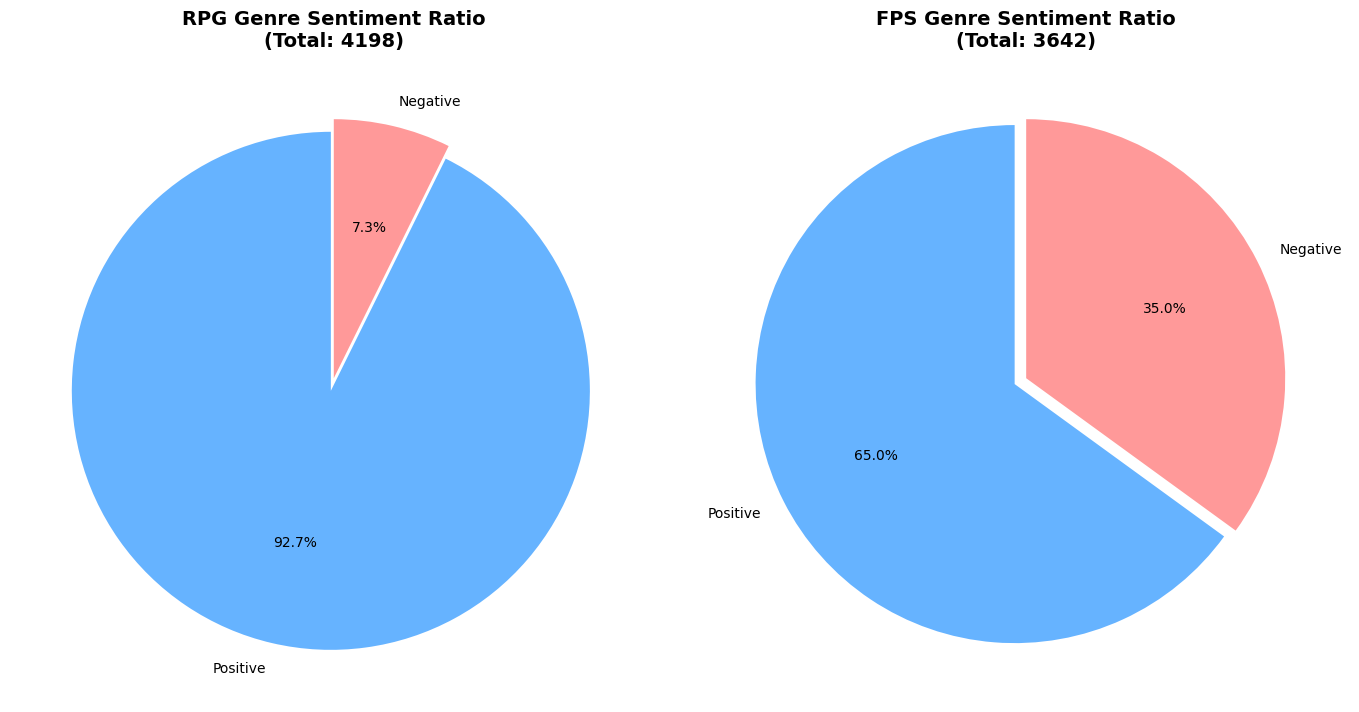

In [8]:
# 장르별 긍정(1)/부정(0) 개수 계산
rpg_pos = (df['Genre'] == 'RPG') & (df['voted_up'] == 1)
rpg_neg = (df['Genre'] == 'RPG') & (df['voted_up'] == 0)
rpg_stats = [len(df[rpg_pos]), len(df[rpg_neg])]

fps_pos = (df['Genre'] == 'FPS') & (df['voted_up'] == 1)
fps_neg = (df['Genre'] == 'FPS') & (df['voted_up'] == 0)
fps_stats = [len(df[fps_pos]), len(df[fps_neg])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# RPG 파이 차트
ax1.pie(rpg_stats, labels=['Positive', 'Negative'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
ax1.set_title(f'RPG Genre Sentiment Ratio\n(Total: {rpg_stats[0]+rpg_stats[1]})', fontsize=14, fontweight='bold')

# FPS 파이 차트
ax2.pie(fps_stats, labels=['Positive', 'Negative'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
ax2.set_title(f'FPS Genre Sentiment Ratio\n(Total: {fps_stats[0]+fps_stats[1]})', fontsize=14, fontweight='bold')

# 그래프 한 번에 출력하기
plt.tight_layout()
plt.show()

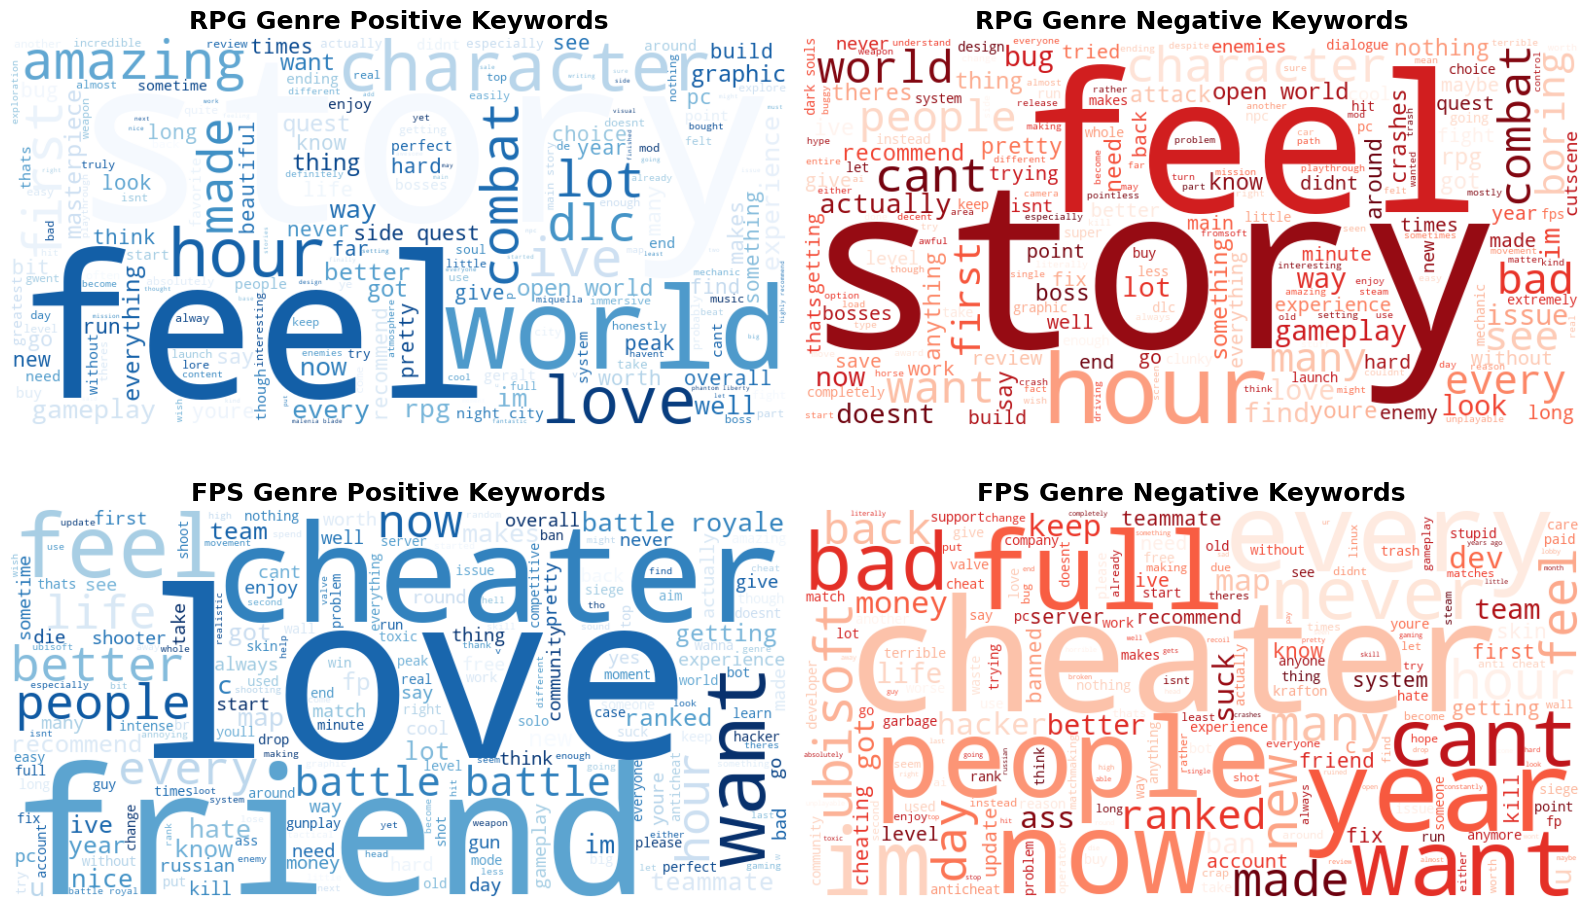

In [27]:
# 불용어 커스텀 설정
# 'game', 'play' 같은 단어는 게임 리뷰에 무조건 등장하므로 이를 제외
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['game', 'games', 'play', 'played', 'playing', 'player', 'players', 'even', 'one', 'really', 'make', 'time', 'much', 'will', 'get', 
                         'fun', 'good', 'best', 'worst', 'dont', 'great', 'still', 'pubg', 'cyberpunk', 'witcher', 'elden', 'ring'])

# 장르별로 텍스트 하나로 뭉치기
rpg_pos_text = " ".join(df[rpg_pos]['clean_review'])
rpg_neg_text = " ".join(df[rpg_neg]['clean_review'])
fps_pos_text = " ".join(df[fps_pos]['clean_review'])
fps_neg_text = " ".join(df[fps_neg]['clean_review'])

# 워드클라우드 이미지 생성 (RPG는 파란색, FPS는 빨간색)
wordcloud_rpg_pos = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Blues').generate(rpg_pos_text)
wordcloud_rpg_neg = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Reds').generate(rpg_neg_text)

wordcloud_fps_pos = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Blues').generate(fps_pos_text)
wordcloud_fps_neg = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Reds').generate(fps_neg_text)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# RPG 영역 (위)
ax1.imshow(wordcloud_rpg_pos, interpolation='bilinear')
ax1.axis('off') # 지저분한 테두리와 눈금선 숨기기
ax1.set_title('RPG Genre Positive Keywords', fontsize=18, fontweight='bold')

ax2.imshow(wordcloud_rpg_neg, interpolation='bilinear')
ax2.axis('off') # 지저분한 테두리와 눈금선 숨기기
ax2.set_title('RPG Genre Negative Keywords', fontsize=18, fontweight='bold')

# FPS 영역 (아래)
ax3.imshow(wordcloud_fps_pos, interpolation='bilinear')
ax3.axis('off')
ax3.set_title('FPS Genre Positive Keywords', fontsize=18, fontweight='bold')

ax4.imshow(wordcloud_fps_neg, interpolation='bilinear')
ax4.axis('off')
ax4.set_title('FPS Genre Negative Keywords', fontsize=18, fontweight='bold')


plt.tight_layout()
plt.show()

<Axes: xlabel='voted_up', ylabel='playtime_forever'>

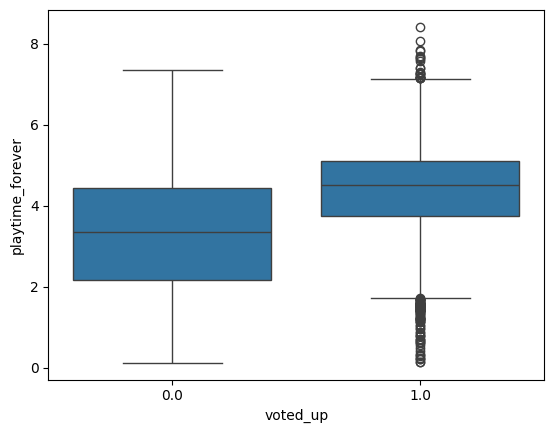

In [9]:
sns.boxplot(data = df[df['Genre'] == 'RPG'], x = 'voted_up', y = np.log1p(df['playtime_forever']))#시각화 개선을 위해 플레이 시간 로그 변환

<Axes: xlabel='voted_up', ylabel='playtime_forever'>

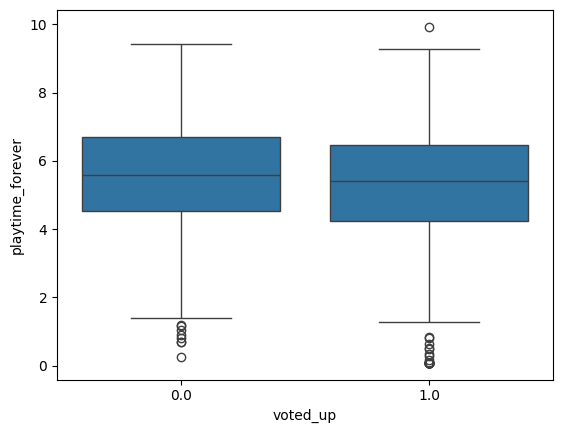

In [10]:
sns.boxplot(data = df[df['Genre'] == 'FPS'], x = 'voted_up', y = np.log1p(df['playtime_forever']))

In [9]:
#키워드가 포함된 리뷰 필터링용 불리언 마스크 생성
def keyword_mask(df, *keywords, match_all=False):
    """
    df: 필터링할 데이터프레임
    *keywords: 검색할 키워드
    match_all: True면 모든 키워드 포함, False면 하나라도 포함
    """
    if not keywords:
        raise ValueError('최소 1개 이상의 키워드를 입력해야 합니다.')
    
    # 각 키워드별 마스크 생성
    masks = [df['clean_review'].str.contains(kw) for kw in keywords]

    # 조건 결합
    if match_all:
        mask = masks[0]
        for m in masks[1:]:
            mask &= m
    else:
        mask = masks[0]
        for m in masks[1:]:
            mask |= m
    
    return mask

In [11]:
#플레이 타임 분포에서 키워드가 포함된 리뷰 데이터 표시
def boxplot_playtime_with_keyword(ax, df, genre, keywords, match_all=False):
    """
    특정 장르의 긍정/부정 리뷰 박스플롯을 그린 뒤,
    keyword_mask()로 선택된 리뷰를 scatter로 겹쳐 표시

    ax: matplotlib axes 객체
    df: 전체 데이터프레임
    genre: 필터링할 장르
    keywords: 검색할 키워드
    match_all: True면 모든 키워드 포함, False면 하나라도 포함
    """
    # 해당 장르 데이터만 추출
    genre_df = df[df['Genre'] == genre].copy()
    
    # 마스크 생성
    mask = keyword_mask(genre_df, *keywords, match_all=match_all)
    
    # 로그 변환된 플레이타임 추가
    genre_df['log_playtime'] = np.log1p(genre_df['playtime_forever'])
    
    # Boxplot
    genre_df.boxplot(column='log_playtime', by='voted_up', ax=ax)
    ax.set_title(f"{genre} Genre (keywords: {', '.join(keywords)})")
    ax.set_xlabel('Sentiment (0=Negative, 1=Positive)')
    ax.set_ylabel('Log Playtime (hours)')
    plt.suptitle("")
    
    # 필터링된 데이터
    filtered = genre_df[mask]
    
    # Scatter plot (red points)
    for i, (val, group) in enumerate(filtered.groupby('voted_up')):
        y = group['log_playtime']
        x = np.random.normal(i+1, 0.04, len(y))  # 그룹 위치에 맞춰서 흩뿌림
        ax.scatter(x, y, color='red', alpha=0.6)

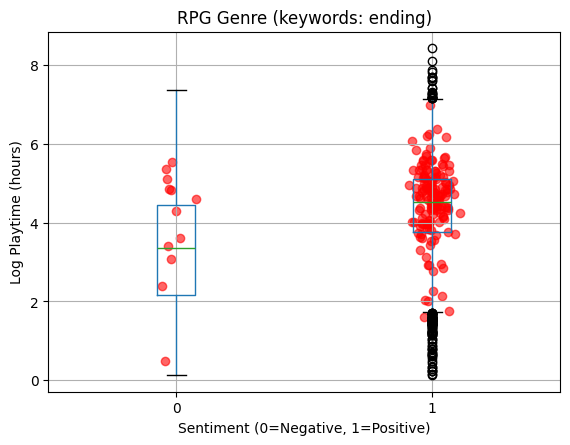

In [13]:
fig, ax = plt.subplots()
boxplot_playtime_with_keyword(ax, df, 'RPG', ['ending'], match_all=False)

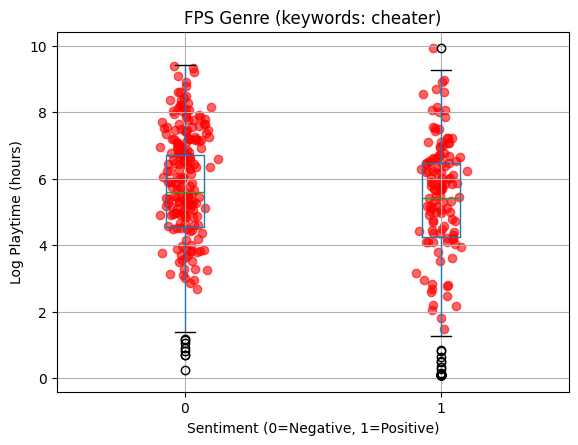

In [12]:
fig, ax = plt.subplots()
boxplot_playtime_with_keyword(ax, df, 'FPS', ['cheater'], match_all=False)

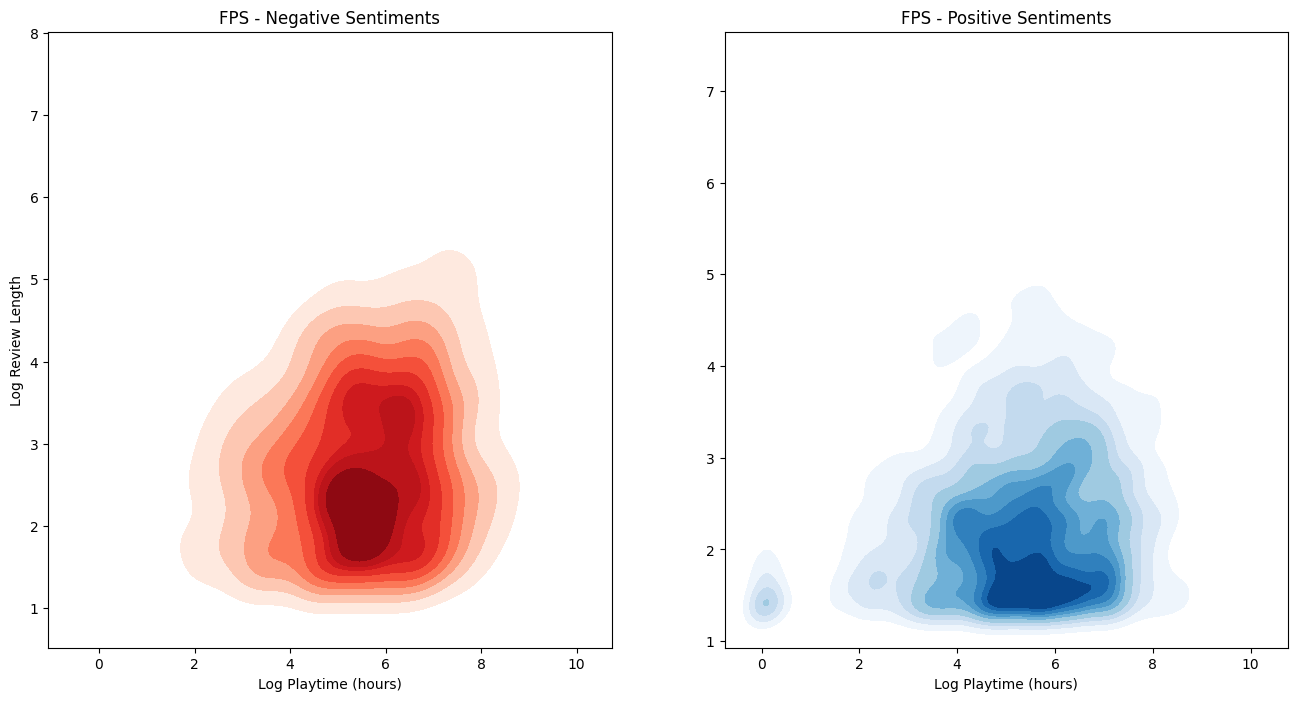

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# FPS 부정
sns.kdeplot(x=np.log1p(df[fps_neg]['playtime_forever']), y=np.log1p(df[fps_neg]['review_length']), 
            fill=True, cmap='Reds', ax=ax1, thresh=0.1, bw_method='silverman', bw_adjust= 0.9)
ax1.set_title('FPS - Negative Sentiments')
ax1.set_xlabel('Log Playtime (hours)')
ax1.set_ylabel('Log Review Length')

# FPS 긍정
sns.kdeplot(x=np.log1p(df[fps_pos]['playtime_forever']), y=np.log1p(df[fps_pos]['review_length']), 
            fill=True, cmap='Blues', ax=ax2, thresh=0.1, bw_method='silverman', bw_adjust= 0.6)
ax2.set_title('FPS - Positive Sentiments')
ax2.set_xlabel('Log Playtime (hours)')
ax2.set_ylabel('');

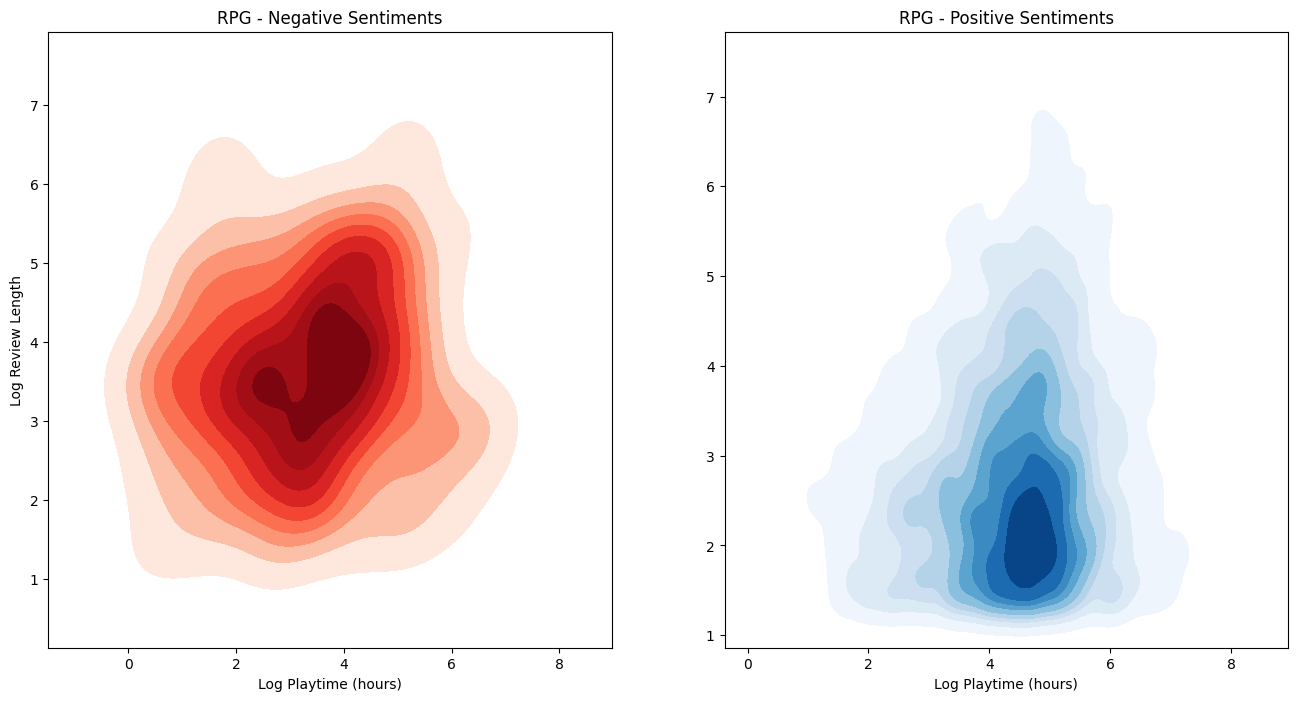

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# RPG 부정
sns.kdeplot(x=np.log1p(df[rpg_neg]['playtime_forever']), y=np.log1p(df[rpg_neg]['review_length']), 
            fill=True, cmap='Reds', ax=ax1, thresh=0.05, bw_method='silverman', bw_adjust= 0.9, weights=weights_neg)
ax1.set_title('RPG - Negative Sentiments')
ax1.set_xlabel('Log Playtime (hours)')
ax1.set_ylabel('Log Review Length')

# RPG 긍정
sns.kdeplot( x=np.log1p(df[rpg_pos]['playtime_forever']), y=np.log1p(df[rpg_pos]['review_length']), 
            fill=True, cmap='Blues', ax=ax2, thresh=0.05, bw_method='silverman', bw_adjust= 0.6, weights=weights_pos)
ax2.set_title('RPG - Positive Sentiments')
ax2.set_xlabel('Log Playtime (hours)')
ax2.set_ylabel('');

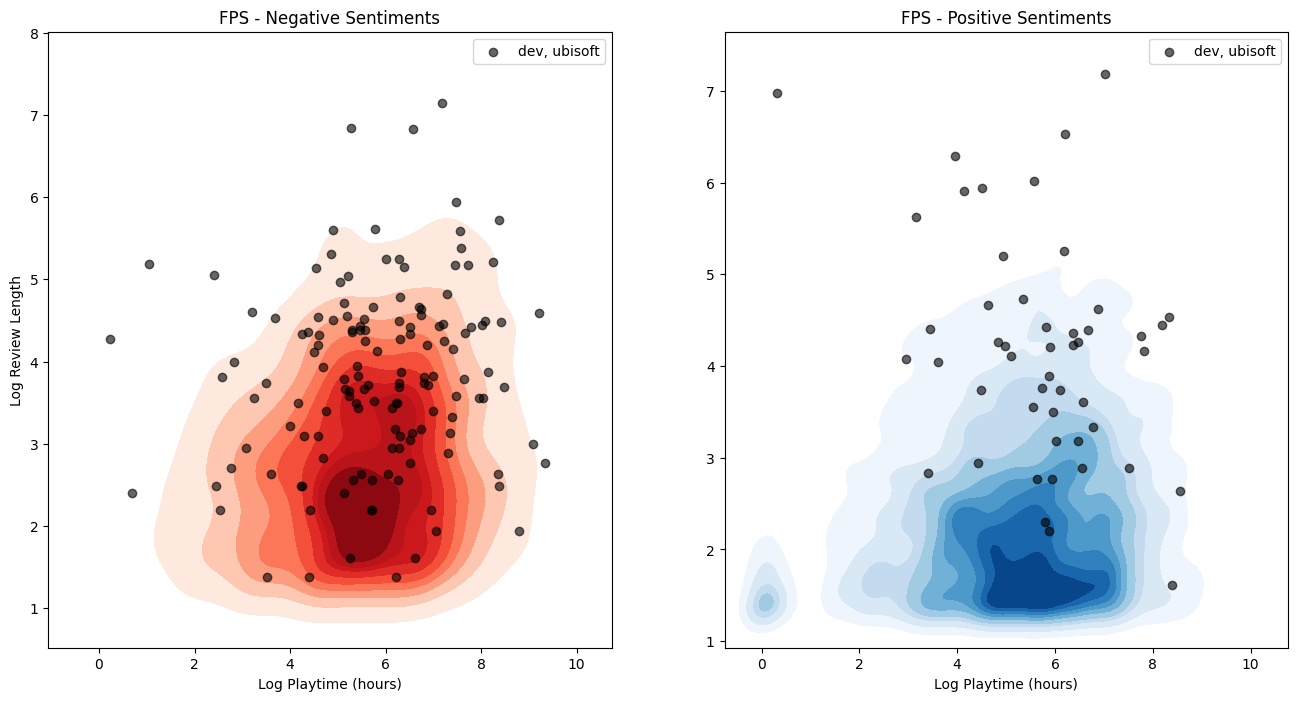

In [35]:
def kdeplot_reviewlen_playtime_with_keyword(df, genre, keywords, match_all=False):
    """
    특정 장르의 긍정/부정 리뷰 KDE를 그린 뒤,
    keyword_mask()로 선택된 리뷰를 scatter로 겹쳐 표시
    
    df: 전체 데이터프레임
    genre: 필터링할 장르
    keywords: 검색할 키워드
    match_all: True면 모든 키워드 포함, False면 하나라도 포함
    """
    # 장르 필터링
    genre_df = df[df['Genre'] == genre].copy()

    # 로그 변환된 열 추가
    genre_df['log_playtime'] = np.log1p(genre_df['playtime_forever'])
    genre_df['log_review_length'] = np.log1p(genre_df['review_length'])

    # 긍정, 부정 분리
    genre_pos = genre_df[genre_df['voted_up'] == 1]
    genre_neg = genre_df[genre_df['voted_up'] == 0]

    # 키워드 필터링
    mask = keyword_mask(genre_df, *keywords, match_all=match_all)
    filtered = genre_df[mask]

    # 서브플롯 생성
    fig, axes = plt.subplots(1, 2, figsize=(16,8))

    # 부정
    sns.kdeplot(data=genre_neg, x='log_playtime', y='log_review_length', fill=True, cmap='Reds', ax=axes[0], thresh=0.05, bw_method='silverman', bw_adjust= 0.9)
    axes[0].set_title(f'{genre} - Negative Sentiments')
    axes[0].set_xlabel('Log Playtime (hours)')
    axes[0].set_ylabel('Log Review Length')

    # 긍정
    sns.kdeplot(data=genre_pos, x='log_playtime', y='log_review_length', fill=True, cmap='Blues', ax=axes[1], thresh=0.05, bw_method='silverman', bw_adjust= 0.6)
    axes[1].set_title(f'{genre} - Positive Sentiments')
    axes[1].set_xlabel('Log Playtime (hours)')
    axes[1].set_ylabel('')

    for val, group in filtered.groupby('voted_up'):
        ax = axes[val]
        x = group['log_playtime']
        y = group['log_review_length']
        ax.scatter(x, y, color='black', alpha=0.6, label=", ".join(keywords))


    # 범례 추가
    axes[0].legend()
    axes[1].legend()


kdeplot_reviewlen_playtime_with_keyword(df, 'FPS', ['dev', 'ubisoft'], match_all=False)